# Bank Marketing TabTransformer Demo

This notebook reproduces the complete experimental pipeline for the final project: dataset download, inspection, preprocessing, baseline training, TabTransformer training, duration ablation, result comparison, and detailed evaluation.

In [1]:
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns

project_root = Path.cwd().resolve()
sys.path.insert(0, str(project_root / 'src'))

/Users/jiangxin/mycode/ML_HW/final_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from evaluate import evaluate_torch_checkpoint
from preprocess import preprocess_data, read_bank_marketing_csv
from train import run_all_experiments
from utils import ensure_dir, load_yaml_config


## 1. Download The Real Dataset

we uses `kagglehub` to fetch the latest dataset version and then selects the full CSV file automatically.

In [5]:
config = load_yaml_config(project_root / 'configs' / 'config.yaml')

download_dir = Path(kagglehub.dataset_download('sushant097/bank-marketing-dataset-full'))
csv_candidates = sorted(download_dir.rglob('*.csv'))
assert csv_candidates, f'No CSV files found in {download_dir}'

downloaded_csv = next((path for path in csv_candidates if path.name == 'bank-full.csv'), csv_candidates[0])
data_dir = ensure_dir(project_root / 'data')
csv_path = data_dir / 'bank-full.csv'
shutil.copy2(downloaded_csv, csv_path)
config['paths']['data_csv'] = str(csv_path)

print('Dataset directory:', download_dir)
print('Copied CSV to:', csv_path)

Dataset directory: /Users/jiangxin/.cache/kagglehub/datasets/sushant097/bank-marketing-dataset-full/versions/1
Copied CSV to: /Users/jiangxin/mycode/ML_HW/final_project/data/bank-full.csv


## 2. Inspect The Dataset

This step confirms the schema, target distribution, and a few high-level descriptive statistics before modeling.

In [6]:
raw_df = read_bank_marketing_csv(csv_path)
print(raw_df.shape)
raw_df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
raw_df.dtypes.to_frame('dtype').T

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
dtype,int64,str,str,str,str,int64,str,str,str,int64,str,int64,int64,int64,int64,str,str


In [8]:
target_summary = raw_df['y'].value_counts(dropna=False).rename_axis('label').reset_index(name='count')
target_summary['ratio'] = target_summary['count'] / target_summary['count'].sum()
target_summary

,label,count,ratio
0,no,39922,0.883015
1,yes,5289,0.116985


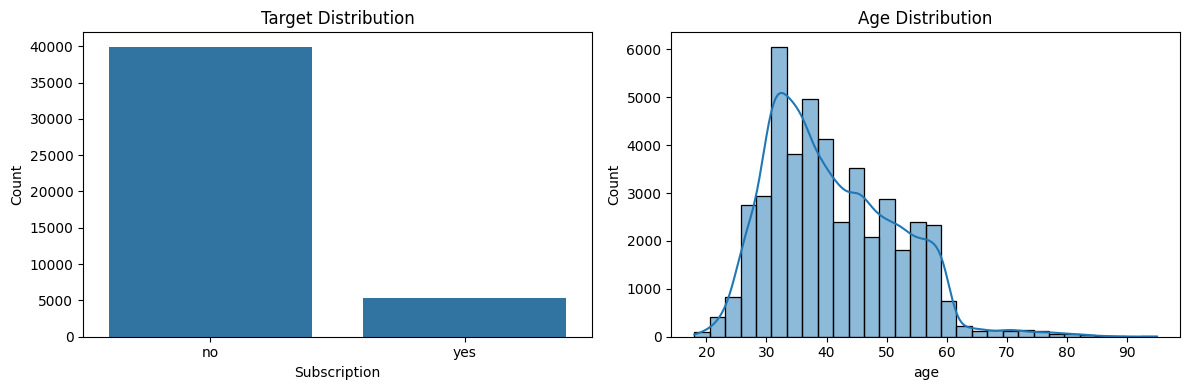

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=raw_df, x='y', ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('Count')

sns.histplot(data=raw_df, x='age', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution')
plt.tight_layout()
plt.show()

## 3. Preprocess Data

We create the embedding-format inputs for PyTorch models and the one-hot format inputs for Logistic Regression using the same stratified split.

In [10]:
metadata = preprocess_data(
    csv_path=csv_path,
    output_dir=project_root / config['paths']['processed_dir'],
    seed=config['training']['seed'],
    include_duration=True,
)
pd.DataFrame({
    'categorical_features': [metadata['categorical_features']],
    'numerical_features': [metadata['numerical_features']],
    'num_train': [metadata['num_train']],
    'num_valid': [metadata['num_valid']],
    'num_test': [metadata['num_test']],
})

,categorical_features,numerical_features,num_train,num_valid,num_test
0,"[job, marital, education, default, housing, lo...","[age, balance, day, duration, campaign, pdays,...",31647,6782,6782


In [11]:
processed = np.load(project_root / config['paths']['processed_dir'] / 'embedding_data.npz')
pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'x_cat_shape': [
        processed['x_cat_train'].shape,
        processed['x_cat_valid'].shape,
        processed['x_cat_test'].shape,
    ],
    'x_num_shape': [
        processed['x_num_train'].shape,
        processed['x_num_valid'].shape,
        processed['x_num_test'].shape,
    ],
    'y_shape': [
        processed['y_train'].shape,
        processed['y_valid'].shape,
        processed['y_test'].shape,
    ],
})

,split,x_cat_shape,x_num_shape,y_shape
0,train,"(31647, 9)","(31647, 7)","(31647,)"
1,valid,"(6782, 9)","(6782, 7)","(6782,)"
2,test,"(6782, 9)","(6782, 7)","(6782,)"


## 4. Run All Experiments

This cell executes the full experiment matrix:

- Logistic Regression
- MLP
- TabTransformer
- with `duration`
- without `duration`


In [12]:
experiment_results = run_all_experiments(config)
experiment_results

Running model=logistic, include_duration=True
Running model=mlp, include_duration=True


{'epoch': 1, 'train_loss': 0.3120905325477314, 'val_loss': 0.2501247836685012, 'train_accuracy': 0.8823269188232692, 'val_accuracy': 0.8973754054851076, 'val_f1': 0.3873239436619718, 'val_roc_auc': 0.8843688636719284}


{'epoch': 2, 'train_loss': 0.23420506199104893, 'val_loss': 0.22137858274586958, 'train_accuracy': 0.9010016747243025, 'val_accuracy': 0.906664700678266, 'val_f1': 0.570264765784114, 'val_roc_auc': 0.9137563540178594}


{'epoch': 3, 'train_loss': 0.2212647583307269, 'val_loss': 0.21662340200042274, 'train_accuracy': 0.9034979618921225, 'val_accuracy': 0.9068121498083161, 'val_f1': 0.5093167701863354, 'val_roc_auc': 0.9181339168681611}


{'epoch': 4, 'train_loss': 0.21609007814484088, 'val_loss': 0.21431483755910408, 'train_accuracy': 0.9054886719120295, 'val_accuracy': 0.904452963727514, 'val_f1': 0.4889589905362776, 'val_roc_auc': 0.920077981319482}


...

{'epoch': 13, 'train_loss': 0.28400857960228204, 'val_loss': 0.29622836591606116, 'train_accuracy': 0.8971782475432111, 'val_accuracy': 0.8960483633146564, 'val_f1': 0.30814524043179586, 'val_roc_auc': 0.7823553277840315}


{'epoch': 14, 'train_loss': 0.2829366888260357, 'val_loss': 0.29084919928730996, 'train_accuracy': 0.8967674661105318, 'val_accuracy': 0.8947213211442052, 'val_f1': 0.3264150943396226, 'val_roc_auc': 0.7870430197086027}


{'epoch': 15, 'train_loss': 0.28189645242166694, 'val_loss': 0.2910741042753336, 'train_accuracy': 0.8971466489714665, 'val_accuracy': 0.8950162194043055, 'val_f1': 0.3219047619047619, 'val_roc_auc': 0.7863556668332466}
Early stopping triggered at epoch 15.


            model  include_duration  accuracy        f1   roc_auc
0        logistic              True  0.901504  0.453355  0.903322
1             mlp              True  0.902094  0.537604  0.919137
2  tabtransformer              True  0.902978  0.543689  0.922081
3        logistic             False  0.896048  0.297109  0.769402
4             mlp             False  0.895606  0.350459  0.786690
5  tabtransformer             False  0.895311  0.314672  0.782418


,accuracy,precision,recall,f1,roc_auc,model,include_duration,test_loss,checkpoint
0,0.901504,0.645688,0.349306,0.453355,0.903322,logistic,True,NaN,NaN
1,0.902094,0.600311,0.486759,0.537604,0.919137,mlp,True,0.213389,checkpoints/mlp_with_duration.pt
2,0.902978,0.604006,0.494325,0.543689,0.922081,tabtransformer,True,0.210586,checkpoints/tabtransformer_with_duration.pt
3,0.896048,0.709524,0.187894,0.297109,0.769402,logistic,False,NaN,NaN
4,0.895606,0.643098,0.240858,0.350459,0.786690,mlp,False,0.289954,checkpoints/mlp_without_duration.pt
5,0.895311,0.670782,0.205549,0.314672,0.782418,tabtransformer,False,0.293357,checkpoints/tabtransformer_without_duration.pt


## 5. Compare Model Performance

We compare the three models on Accuracy, F1, and ROC-AUC, and then inspect the effect of removing `duration`.

In [13]:
comparison_table = experiment_results[['model', 'include_duration', 'accuracy', 'f1', 'roc_auc']].copy()
comparison_table = comparison_table.sort_values(['include_duration', 'roc_auc'], ascending=[False, False])
comparison_table

,model,include_duration,accuracy,f1,roc_auc
2,tabtransformer,True,0.902978,0.543689,0.922081
1,mlp,True,0.902094,0.537604,0.919137
0,logistic,True,0.901504,0.453355,0.903322
4,mlp,False,0.895606,0.350459,0.786690
5,tabtransformer,False,0.895311,0.314672,0.782418
3,logistic,False,0.896048,0.297109,0.769402


In [14]:
pivot_auc = experiment_results.pivot(index='model', columns='include_duration', values='roc_auc')
pivot_auc.columns = ['without_duration' if c is False else 'with_duration' for c in pivot_auc.columns]
pivot_auc['delta_auc'] = pivot_auc['with_duration'] - pivot_auc['without_duration']
pivot_auc.sort_values('with_duration', ascending=False)

,without_duration,with_duration,delta_auc
model,,,
tabtransformer,0.782418,0.922081,0.139663
mlp,0.786690,0.919137,0.132446
logistic,0.769402,0.903322,0.133920


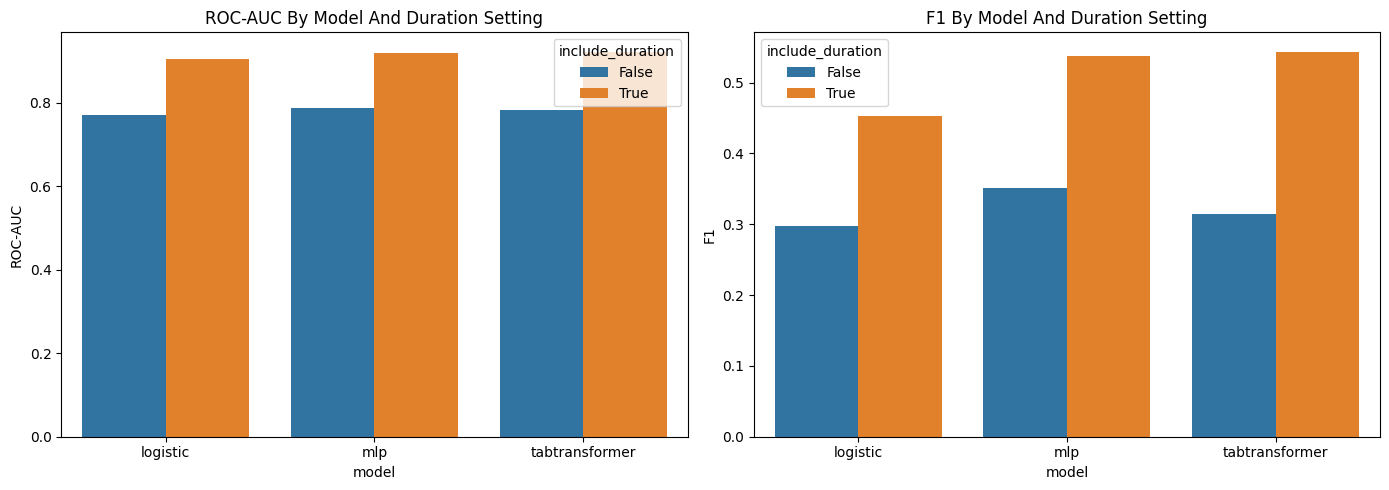

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=experiment_results, x='model', y='roc_auc', hue='include_duration', ax=axes[0])
axes[0].set_title('ROC-AUC By Model And Duration Setting')
axes[0].set_ylabel('ROC-AUC')

sns.barplot(data=experiment_results, x='model', y='f1', hue='include_duration', ax=axes[1])
axes[1].set_title('F1 By Model And Duration Setting')
axes[1].set_ylabel('F1')

plt.tight_layout()
plt.show()

## 6. Detailed Evaluation For The Main Model

We evaluate the `TabTransformer` checkpoint trained with `duration`.

In [16]:
preprocess_data(
    csv_path=project_root / config['paths']['data_csv'],
    output_dir=project_root / config['paths']['processed_dir'],
    seed=config['training']['seed'],
    include_duration=True,
)


{'target_column': 'y',
 'categorical_features': ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'],
 'numerical_features': ['age',
  'balance',
  'day',
  'duration',
  'campaign',
  'pdays',
  'previous'],
 'categorical_cardinalities': {'job': 13,
  'marital': 4,
  'education': 5,
  'default': 3,
  'housing': 3,
  'loan': 3,
  'contact': 4,
  'month': 13,
  'poutcome': 5},
 'categorical_encoders': {'job': {'__unknown__': 0,
   'admin.': 1,
   'blue-collar': 2,
   'entrepreneur': 3,
   'housemaid': 4,
   'management': 5,
   'retired': 6,
   'self-employed': 7,
   'services': 8,
   'student': 9,
   'technician': 10,
   'unemployed': 11,
   'unknown': 12},
  'marital': {'__unknown__': 0, 'divorced': 1, 'married': 2, 'single': 3},
  'education': {'__unknown__': 0,
   'primary': 1,
   'secondary': 2,
   'tertiary': 3,
   'unknown': 4},
  'default': {'__unknown__': 0, 'no': 1, 'yes': 2},
  'housing': {'__unknown__': 0, 'no': 1, 'yes

In [17]:
metrics, y_true, y_prob = evaluate_torch_checkpoint(
    checkpoint_path=project_root / 'checkpoints' / 'tabtransformer_with_duration.pt',
    processed_dir=project_root / config['paths']['processed_dir'],
    results_dir=project_root / config['paths']['results_dir'],
    batch_size=config['training']['batch_size'],
)
pd.DataFrame([metrics])

,accuracy,precision,recall,f1,roc_auc,model
0,0.902978,0.604006,0.494325,0.543689,0.922081,tabtransformer


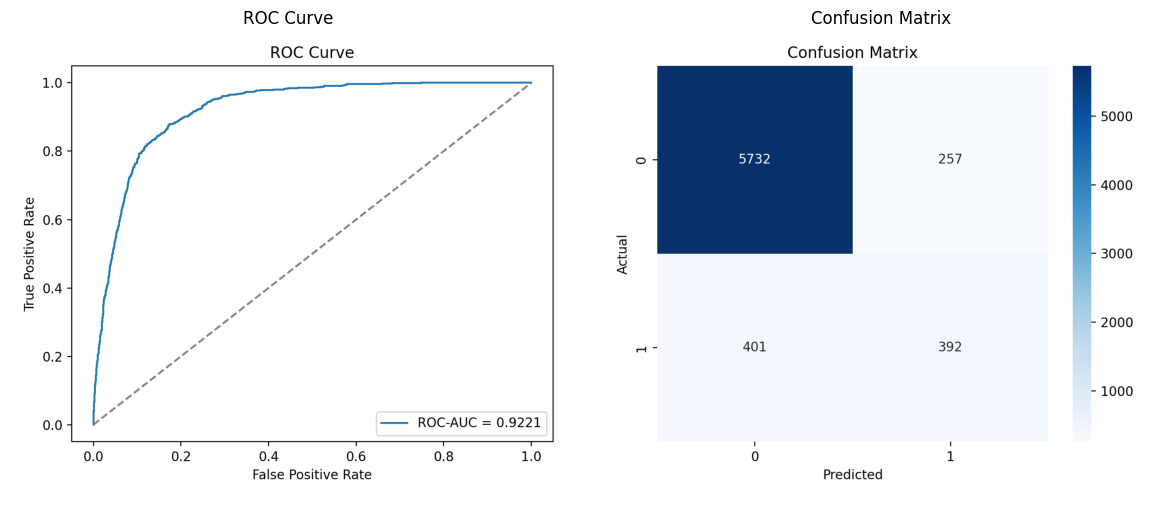

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_img = plt.imread(project_root / 'results' / 'roc_curve.png')
cm_img = plt.imread(project_root / 'results' / 'confusion_matrix.png')

axes[0].imshow(roc_img)
axes[0].axis('off')
axes[0].set_title('ROC Curve')

axes[1].imshow(cm_img)
axes[1].axis('off')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()